# 05 — Simulation from WBIC MAP Estimates

For each session, uses the per-session MAP parameters from WBIC fitting
(`04_wbic_fitting.ipynb`) to simulate the RL agent on the **exact same block
structure** as the experiment.  Two metrics are compared against the real data:

1. **Stay probability** — 4 conditions: rewarded×common, rewarded×rare,
   unrewarded×common, unrewarded×rare (FC→FC transitions only).
2. **Trials to criterion** — number of free-choice trials after each block
   reversal until the EMA of correct choices exceeds 75%.

**Models** : `mf_p`, `mb_p`, `hyb_p`, `rac_p`  
**Stages** : 4.2 – 4.8 (processes whichever WBIC CSVs exist)  
**Output** : `results/simulation/sim_{model}_{stage}.csv` — one row per session

**Prerequisites**: run `04_wbic_fitting.ipynb` for the desired (model × stage)
combinations first.

---
### Block state encoding (from raw `B:XY` field in pyControl data)
| `d[8][2]` | Meaning | `B` value |
|-----------|---------|----------|
| `D` | down state rewarded | 0 |
| `U` | up state rewarded   | 1 |
| `N` | neutral (50/50)     | 2 |

The correct first-step choice is the one that leads most often to the
currently-rewarded second state (determined by PR/PL and the block state).

In [1]:
# ── Cell 1: Configuration ─────────────────────────────────────────────────

MODELS_TO_SIM = ['mf_p', 'mb_p', 'hyb_p']
STAGES        = ['4.2', '4.3', '4.4', '4.5', '4.6', '4.7', '4.8']

N_SIM        = 100   # simulation repetitions per session
EMA_TAU      = 8     # exponential moving average time constant
EMA_CRITERION = 0.75  # criterion threshold for block reversal
SEED         = 21

# Set True to re-run even if the output CSV already exists
FORCE_RERUN = False


In [2]:
# ── Cell 2: Imports & path setup ──────────────────────────────────────────

import sys, os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    _organized = os.path.dirname(_here)
else:
    _organized = os.path.join(_here, 'organized')
    if not os.path.isdir(_organized):
        _organized = _here
sys.path.insert(0, _organized)
sys.path.insert(0, os.path.join(_organized, 'src'))

from config import (
    SUBJECTS, RAW_DATA_DIR,
    raw_subject_dir, wbic_result_csv, sim_result_csv, FIGURES_DIR
)
from src.data_import import Experiment
from src.wbic import WBIC_MODELS

rng = np.random.default_rng(SEED)
print('Organized root:', _organized)
print('Subjects:', SUBJECTS)

Organized root: /gpfs/radev/project/kuan/my483/RL_twostep/organized
Subjects: ['WT1', 'WT2', 'WT3', 'WT4', 'WT5', 'WT6']


In [3]:
# ── Cell 3: Session loading helper ────────────────────────────────────────
# (mirrors 04_wbic_fitting.ipynb exactly)
#
# Stage '4.8' is special: sessions in the main folder have training_stage=='4.7'
# in the raw file, so we load ALL sessions from the main folder without filtering.
# Stages '4.2'–'4.7' use ONLY the _Training folder, filtered by training_stage.
#
# Important: do NOT load from both folders for training stages — the main folder
# sessions also have training_stage=='4.7' internally (they are the 4.8 experiment
# sessions), so including them in stage 4.7 would double-count them.

def load_sessions(subject, stage):
    """Return all sessions for a subject at the given analysis stage."""
    if stage == '4.8':
        # Final experiment sessions: main folder, no filter
        folder = raw_subject_dir(subject, training=False)
        if not os.path.isdir(folder):
            return []
        exp = Experiment(folder)
        sessions = list(exp.sessions)
    else:
        # Training stages: _Training folder only
        folder = raw_subject_dir(subject, training=True)
        if not os.path.isdir(folder):
            return []
        exp = Experiment(folder)
        sessions = [s for s in exp.sessions if s.training_stage == stage]

    seen, unique = set(), []
    for s in sorted(sessions, key=lambda s: s.datetime_string):
        if s.file_name not in seen:
            seen.add(s.file_name)
            unique.append(s)
    return unique

In [4]:
# ── Cell 4: Full session parser (extends RL_data_arrange_single + B array) ─
#
# Raw print-line format (space-separated, 'P ' prefix already stripped):
#   d[0]=time  d[1]=T#  d[2]=R#  d[3]=B#  d[4]=C:  d[5]=S:  d[6]=O:
#   d[7]=CA:   d[8]=B:XY  d[9]=CT:  d[10]=TS:
#
# d[8] encodes two things:
#   d[8][2] — reward block: D=down rewarded (0), U=up rewarded (1), N=neutral (2)
#   d[8][3] — transition type: A or B  (determines PR/PL; constant per session)

BLOCK_CHAR = {'D': 0, 'U': 1, 'N': 2}

def parse_session_full(session):
    """Parse a pyControl session into arrays needed for simulation.

    Returns
    -------
    T    : int             — number of trials
    c    : int[T]          — experimental choices (1=left, 2=right)
    ss   : int[T]          — second states (1=up, 2=down)
    tt   : int[T]          — trial types (1=free choice, 2=forced)
    r    : float[T]        — outcomes (1.0=rewarded, 0.0=not)
    PR   : float[2]        — right-choice transition probs [P(up), P(down)]
    PL   : float[2]        — left-choice transition probs  [P(up), P(down)]
    B    : int[T]          — block state (0=D, 1=U, 2=N)
    """
    b = session.print_lines
    T = len(b)

    trial0 = b[0].split(' ')
    trans_state = int(trial0[8][3] == 'A')
    if trans_state:
        PL = np.array([0.8, 0.2])
        PR = np.array([0.2, 0.8])
    else:
        PL = np.array([0.2, 0.8])
        PR = np.array([0.8, 0.2])

    c  = np.ones(T, dtype=int)
    ss = np.ones(T, dtype=int)
    tt = np.ones(T, dtype=int)
    r  = np.zeros(T)
    B  = np.zeros(T, dtype=int)

    for j in range(T):
        d = b[j].split(' ')
        if d[4] == 'C:0':   c[j]  = 2
        if d[5] == 'S:0':   ss[j] = 2
        r[j]  = 1.0 if d[6] == 'O:1' else 0.0
        if d[9] != 'CT:FC': tt[j] = 2
        B[j]  = BLOCK_CHAR.get(d[8][2], 2)

    return T, c, ss, tt, r, PR, PL, B

In [5]:
# ── Cell 5: Reward-probability lookup ──────────────────────────────────────
#
# Key: (block_state, second_state)  block: 0=D(down rewarded), 1=U(up rewarded)
#                                   ss:    1=up, 2=down
#
# Stages 4.2–4.6: high=0.9, low=0.1
# Stages 4.7–4.8: high=0.8, low=0.2
# Neutral block (B=2): 0.5 for both states

def _reward_table(high, low):
    return {
        (0, 1): low,   # D block, up state  → low reward
        (0, 2): high,  # D block, down state → high reward
        (1, 1): high,  # U block, up state  → high reward
        (1, 2): low,   # U block, down state → low reward
        (2, 1): 0.5,   # neutral
        (2, 2): 0.5,
    }

REWARD_PROBS = {
    '4.2': _reward_table(0.9, 0.1),
    '4.3': _reward_table(0.9, 0.1),
    '4.4': _reward_table(0.9, 0.1),
    '4.5': _reward_table(0.9, 0.1),
    '4.6': _reward_table(0.9, 0.1),
    '4.7': _reward_table(0.8, 0.2),
    '4.8': _reward_table(0.8, 0.2),
}

def _correct_choice(block_state, PR, PL):
    """Return the correct first-step choice (1=left, 2=right) given block state."""
    if block_state == 0:   # down (ss=2) rewarded — pick choice that leads most to down
        return 1 if PL[1] > PR[1] else 2
    elif block_state == 1:  # up (ss=1) rewarded
        return 1 if PL[0] > PR[0] else 2
    return None  # neutral block

In [6]:
# ── Cell 6: Per-model simulation steps ────────────────────────────────────
#
# Each _sim_<model> function generates one trajectory of length T.
# Free-choice trials: action chosen via softmax on Q values.
# Forced-choice trials: use experimental choice, second state, AND reward

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))


def _sample_outcome(c_t, PR, PL, B_t, reward_probs, rng_obj):
    """Sample second state and reward for a FREE-CHOICE trial."""
    trans = PL if c_t == 1 else PR
    ss_t = 1 if rng_obj.random() < trans[0] else 2
    p_rew = reward_probs.get((int(B_t), ss_t), 0.5)
    r_t = 1.0 if rng_obj.random() < p_rew else 0.0
    return ss_t, r_t


def _sim_mf_p(param, T, tt, c_exp, ss_exp, r_exp, PR, PL, B, reward_probs, rng_obj):
    alpha  = param['alpha']
    lamda  = param['lambda']
    forget = param['forget']
    Wmf    = param['Wmf']
    P      = param['P']

    c_out  = np.zeros(T, dtype=int)
    ss_out = np.zeros(T, dtype=int)
    r_out  = np.zeros(T)

    Qmf  = np.zeros(2)
    V    = np.zeros(2)
    Qnet = np.zeros(2)
    prev_c = 0.0

    for t in range(T):
        p_left = _sigmoid(Qnet[0] - Qnet[1])
        if tt[t] == 1:   # free choice: sample action, ss, reward
            c_out[t]  = 1 if rng_obj.random() < p_left else 2
            ss_out[t], r_out[t] = _sample_outcome(c_out[t], PR, PL, B[t], reward_probs, rng_obj)
        else:             # forced choice: replay experimental c, ss, r
            c_out[t]  = c_exp[t]
            ss_out[t] = ss_exp[t]
            r_out[t]  = r_exp[t]

        if t < T - 1:
            ci = c_out[t] - 1
            nc = 2 - c_out[t]
            si = ss_out[t] - 1
            ns = 2 - ss_out[t]
            Qmf[ci] = (1-alpha)*Qmf[ci] + alpha*(lamda*r_out[t] - (1-lamda)*V[si])
            Qmf[nc] = (1-forget)*Qmf[nc]
            V[si]   = (1-alpha)*V[si]  + alpha*r_out[t]
            V[ns]   = (1-forget)*V[ns]
            prev_c  = 0.5 if ci == 0 else -0.5
            Qnet[0] = Wmf*Qmf[0] + P*prev_c
            Qnet[1] = Wmf*Qmf[1]

    return c_out, ss_out, r_out


def _sim_mb_p(param, T, tt, c_exp, ss_exp, r_exp, PR, PL, B, reward_probs, rng_obj):
    alpha  = param['alpha']
    forget = param['forget']
    Wmb    = param['Wmb']
    P      = param['P']

    c_out  = np.zeros(T, dtype=int)
    ss_out = np.zeros(T, dtype=int)
    r_out  = np.zeros(T)

    V    = np.zeros(2)
    Qmb  = np.zeros(2)
    Qnet = np.zeros(2)
    prev_c = 0.0

    for t in range(T):
        p_left = _sigmoid(Qnet[0] - Qnet[1])
        if tt[t] == 1:
            c_out[t]  = 1 if rng_obj.random() < p_left else 2
            ss_out[t], r_out[t] = _sample_outcome(c_out[t], PR, PL, B[t], reward_probs, rng_obj)
        else:
            c_out[t]  = c_exp[t]
            ss_out[t] = ss_exp[t]
            r_out[t]  = r_exp[t]

        if t < T - 1:
            si = ss_out[t] - 1
            ns = 2 - ss_out[t]
            V[si]   = (1-alpha)*V[si]  + alpha*r_out[t]
            V[ns]   = (1-forget)*V[ns]
            Qmb[0]  = PL[0]*V[0] + PL[1]*V[1]
            Qmb[1]  = PR[0]*V[0] + PR[1]*V[1]
            prev_c  = 0.5 if (c_out[t]-1) == 0 else -0.5
            Qnet[0] = Wmb*Qmb[0] + P*prev_c
            Qnet[1] = Wmb*Qmb[1]

    return c_out, ss_out, r_out


def _sim_hyb_p(param, T, tt, c_exp, ss_exp, r_exp, PR, PL, B, reward_probs, rng_obj):
    alpha  = param['alpha']
    lamda  = param['lambda']
    forget = param['forget']
    Wmf    = param['Wmf']
    Wmb    = param['Wmb']
    P      = param['P']

    c_out  = np.zeros(T, dtype=int)
    ss_out = np.zeros(T, dtype=int)
    r_out  = np.zeros(T)

    Qmf  = np.zeros(2)
    V    = np.zeros(2)
    Qmb  = np.zeros(2)
    Qnet = np.zeros(2)
    prev_c = 0.0

    for t in range(T):
        p_left = _sigmoid(Qnet[0] - Qnet[1])
        if tt[t] == 1:
            c_out[t]  = 1 if rng_obj.random() < p_left else 2
            ss_out[t], r_out[t] = _sample_outcome(c_out[t], PR, PL, B[t], reward_probs, rng_obj)
        else:
            c_out[t]  = c_exp[t]
            ss_out[t] = ss_exp[t]
            r_out[t]  = r_exp[t]

        if t < T - 1:
            ci = c_out[t] - 1
            nc = 2 - c_out[t]
            si = ss_out[t] - 1
            ns = 2 - ss_out[t]
            Qmf[ci] = (1-alpha)*Qmf[ci] + alpha*(lamda*r_out[t] + (1-lamda)*V[si])
            Qmf[nc] = (1-forget)*Qmf[nc]
            V[si]   = (1-alpha)*V[si]  + alpha*r_out[t]
            V[ns]   = (1-forget)*V[ns]
            Qmb[0]  = PL[0]*V[0] + PL[1]*V[1]
            Qmb[1]  = PR[0]*V[0] + PR[1]*V[1]
            prev_c  = 0.5 if ci == 0 else -0.5
            Qnet[0] = Wmb*Qmb[0] + Wmf*Qmf[0] + P*prev_c
            Qnet[1] = Wmb*Qmb[1] + Wmf*Qmf[1]

    return c_out, ss_out, r_out


def _sim_rac_p(param, T, tt, c_exp, ss_exp, r_exp, PR, PL, B, reward_probs, rng_obj):
    """Reward-as-cue + perseveration."""
    alpha     = param['alpha']
    beta_temp = param['tmp']
    P         = param['P']

    c_out  = np.zeros(T, dtype=int)
    ss_out = np.zeros(T, dtype=int)
    r_out  = np.zeros(T)

    Q_td   = np.full((2, 2, 2), 0.5)
    q1     = np.array([0.5, 0.5])
    prev_c = 0.0
    ps, po = 0, 0

    for t in range(T):
        p_left = _sigmoid(beta_temp * (q1[0] - q1[1]))
        if tt[t] == 1:
            c_out[t]  = 1 if rng_obj.random() < p_left else 2
            ss_out[t], r_out[t] = _sample_outcome(c_out[t], PR, PL, B[t], reward_probs, rng_obj)
        else:
            c_out[t]  = c_exp[t]
            ss_out[t] = ss_exp[t]
            r_out[t]  = r_exp[t]

        if t < T - 1:
            ci     = c_out[t] - 1
            prev_c = 0.5 if ci == 0 else -0.5
            Q_td[ci, ps, po] = (1-alpha)*Q_td[ci, ps, po] + alpha*r_out[t]
            ps = ss_out[t] - 1
            po = int(r_out[t])
            q1[0] = Q_td[0, ps, po] + P*prev_c
            q1[1] = Q_td[1, ps, po]

    return c_out, ss_out, r_out


_SIM_FN = {
    'mf_p':  _sim_mf_p,
    'mb_p':  _sim_mb_p,
    'hyb_p': _sim_hyb_p,
    'rac_p': _sim_rac_p,
}


def simulate_session(model_key, param, T, tt, c_exp, ss_exp, r_exp, PR, PL, B, stage, n_sim, rng_obj):
    """Run n_sim simulation trajectories for one session."""
    fn = _SIM_FN[model_key]
    reward_probs = REWARD_PROBS[stage]
    c_sims  = np.zeros((n_sim, T), dtype=int)
    ss_sims = np.zeros((n_sim, T), dtype=int)
    r_sims  = np.zeros((n_sim, T))
    for i in range(n_sim):
        c_sims[i], ss_sims[i], r_sims[i] = fn(
            param, T, tt, c_exp, ss_exp, r_exp, PR, PL, B, reward_probs, rng_obj
        )
    return c_sims, ss_sims, r_sims


In [7]:
# ── Cell 7: Stay probability ───────────────────────────────────────────────
#
# Computed only over consecutive FC→FC trial pairs (tt[t]==1 AND tt[t+1]==1).
# 4 conditions (indexed 0-3):
#   0: rewarded   + common transition
#   1: rewarded   + rare   transition
#   2: unrewarded + common transition
#   3: unrewarded + rare   transition
#
# Common/rare determined by transition type (PL[0]):
#   Type A (PL[0] = 0.8):  c[t] == ss[t]  → common
#   Type B (PL[0] = 0.2):  c[t] != ss[t]  → common
#
# Mirrors the logic in OIST/04a_simulation_model_free.ipynb Cell 108.

def compute_stay_prob(c, ss, r, tt, PR, PL):
    """Return stay probability for 4 conditions (NaN if no data in that cell).

    Parameters
    ----------
    c, ss, r, tt : int/float arrays of length T
    PR, PL       : transition probability arrays (length 2)

    Returns
    -------
    np.ndarray of shape (4,): [rew_com, rew_rare, unrew_com, unrew_rare]
    """
    stay  = np.zeros(4)
    total = np.zeros(4)
    T = len(c)

    for t in range(T - 1):
        # Only adjacent FC->FC pairs
        if tt[t] != 1 or tt[t + 1] != 1:
            continue

        # Common/rare: depends on transition type (A vs B)
        if PL[0] > 0.5:          # Type A: PL[0]=0.8, matching = common
            is_common = (c[t] == ss[t])
        else:                     # Type B: PL[0]=0.2, non-matching = common
            is_common = (c[t] != ss[t])

        rew_idx  = 0 if r[t] == 1.0 else 1   # 0=rewarded, 1=unrewarded
        comm_idx = 0 if is_common else 1      # 0=common,   1=rare
        cond     = rew_idx * 2 + comm_idx     # 0, 1, 2, 3

        stay[cond]  += int(c[t + 1] == c[t])
        total[cond] += 1

    return np.where(total > 0, stay / total, np.nan)


In [8]:
# ── Cell 8: Trials to criterion ───────────────────────────────────────────
#
# Matches OIST numTrial_blockR_tr logic exactly:
#
#  1. EMA flip: when criterion is met and the next trial is in a non-neutral
#     block, EMA is set to (1 - value) rather than reset to 0.5.  This carries
#     over the learned state (inverted) into the next block.  EMA resets to 0.5
#     only when the next block is neutral or the session ends.
#
#  2. Count convention: currentT is incremented AFTER the criterion check, so
#     the trial on which criterion is reached is NOT included in the count.
#
#  3. Neutral blocks: reset both EMA and currentT.
#
#  4. blockR flag: set True once criterion is reached in a block; cleared on
#     any block transition so counting restarts in the new block.
#
#  5. incomplete_fallback: if True and no reversal was completed in the whole
#     session, append currentT at end (matches OIST numTrial_blockR_tr for
#     training stages 4.5–4.7 where early sessions may never reach criterion).
#     Stage 4.8 uses numTrial_blockR_ex which does NOT have this fallback.

def trials_to_criterion(c, tt, B, PR, PL, tau=EMA_TAU, criterion=EMA_CRITERION,
                        incomplete_fallback=False):
    """Return list of FC-trial counts to criterion for each reversal reached.

    Parameters
    ----------
    incomplete_fallback : bool
        If True and no reversal criterion was reached (results is empty at
        end of session), append currentT.  Set True for training stages
        4.2–4.7 to match OIST numTrial_blockR_tr; False for stage 4.8.
    """
    m_decay = math.exp(-1.0 / tau)
    m_incr  = 1.0 - m_decay
    T       = len(c)

    def _cc(t):
        """Correct choice at trial t (0 = neutral block)."""
        cc = _correct_choice(int(B[t]), PR, PL)
        return cc if cc is not None else 0

    results  = []
    ema      = 0.5
    blockR   = False
    currentT = 0

    for t in range(T):
        # Any block transition re-opens the block (look for criterion again)
        if t > 0 and B[t - 1] != B[t]:
            blockR = False

        cc = _cc(t)

        # ── Update EMA and check criterion ────────────────────────────────
        # Only on FC trials in non-neutral blocks when criterion not yet met
        if cc != 0 and tt[t] == 1 and not blockR:
            ema = m_decay * ema + m_incr * int(c[t] == cc)
            if ema > criterion:
                results.append(currentT)
                currentT = 0
                # Flip EMA if next trial belongs to a non-neutral block;
                # otherwise reset (matches OIST MA.value = 1 - MA.value logic)
                if t < T - 1 and _cc(t + 1) != 0:
                    ema = 1.0 - ema
                else:
                    ema = 0.5
                blockR = True

        # ── Count FC trials where criterion has not yet been met ──────────
        if cc != 0 and not blockR and ema <= criterion and tt[t] == 1:
            currentT += 1
        elif cc == 0:          # neutral block: reset count and EMA
            currentT = 0
            ema = 0.5

    # End-of-session fallback: if no reversal criterion was reached at all,
    # record the running trial count — matches OIST numTrial_blockR_tr
    if incomplete_fallback and not results:
        results.append(currentT)

    return results


In [9]:
# ── Cell 9: Main loop ─────────────────────────────────────────────────────
#
# For each (model × stage) with an existing WBIC CSV:
#   1. Load WBIC parameters (one row per session)
#   2. Load session data (parse_session_full)
#   3. Run N_SIM simulations → stay prob + TTC
#   4. Compute experimental stay prob + TTC for the same session
#   5. Save all results to sim_{model}_{stage}.csv
#
# TTC columns saved:
#   exp_ttc_list / sim_ttc_list : semicolon-separated individual reversal values
#   exp_ttc_mean / sim_ttc_mean : per-session mean (for quick inspection)
#   exp_ttc_n    / sim_ttc_n    : number of reversals in session
#
# incomplete_fallback=True for training stages 4.2–4.7: sessions that never
# reach criterion contribute currentT (matches OIST numTrial_blockR_tr).
# Stage 4.8 uses False (matches OIST numTrial_blockR_ex, no fallback).

for model_key in MODELS_TO_SIM:
    param_names = WBIC_MODELS[model_key].param_names

    for stage in STAGES:
        out_csv  = sim_result_csv(model_key, stage)
        wbic_csv = wbic_result_csv(model_key, stage)

        if not os.path.exists(wbic_csv):
            print(f'[{model_key} | {stage}] WBIC CSV not found — skipping '
                  f'(run 04_wbic_fitting.ipynb first)')
            continue

        if not FORCE_RERUN and os.path.exists(out_csv):
            print(f'[{model_key} | {stage}] result CSV exists — skipping.')
            continue

        df_wbic = pd.read_csv(wbic_csv)
        # Training stages use incomplete_fallback to match OIST numTrial_blockR_tr
        ttc_fallback = (stage != '4.8')
        print(f'\n=== [{model_key} | stage {stage}] (ttc_fallback={ttc_fallback}) ===')
        rows = []

        for subject in SUBJECTS:
            sessions  = load_sessions(subject, stage)
            sess_rows = df_wbic[df_wbic['subject'] == subject]

            if not sessions or sess_rows.empty:
                continue

            print(f'  {subject}: {len(sessions)} sessions', flush=True)

            for sess_idx, session in enumerate(sessions):
                wrow = sess_rows[sess_rows['session_idx'] == sess_idx]
                if wrow.empty:
                    continue

                try:
                    T, c_exp, ss_exp, tt, r_exp, PR, PL, B = parse_session_full(session)
                    param = {p: float(wrow[p].values[0]) for p in param_names}

                    # ── Simulate ──────────────────────────────────────────
                    c_sims, ss_sims, r_sims = simulate_session(
                        model_key, param, T, tt, c_exp, ss_exp, r_exp, PR, PL, B, stage, N_SIM, rng
                    )

                    # ── Stay probability ──────────────────────────────────
                    sim_stays = np.array([
                        compute_stay_prob(c_sims[i], ss_sims[i], r_sims[i], tt, PR, PL)
                        for i in range(N_SIM)
                    ])  # shape (N_SIM, 4)
                    exp_stay = compute_stay_prob(c_exp, ss_exp, r_exp, tt, PR, PL)

                    # ── Trials to criterion (individual reversal values) ───
                    # incomplete_fallback: True for training stages (matches OIST
                    # numTrial_blockR_tr), False for stage 4.8 (numTrial_blockR_ex)
                    sim_ttc_all = []
                    for i in range(N_SIM):
                        sim_ttc_all.extend(
                            trials_to_criterion(c_sims[i], tt, B, PR, PL,
                                                incomplete_fallback=ttc_fallback)
                        )

                    exp_ttc_all = trials_to_criterion(c_exp, tt, B, PR, PL,
                                                      incomplete_fallback=ttc_fallback)

                    # ── Assemble result row ───────────────────────────────
                    row = {
                        'model':       model_key,
                        'stage':       stage,
                        'subject':     subject,
                        'session_idx': sess_idx,
                        'date':        session.datetime_string,
                        'n_trials':    T,
                    }

                    # stay probability per condition (sim mean, 2.5/97.5 pct)
                    COND_LABELS = ['rew_com', 'rew_rare', 'unrew_com', 'unrew_rare']
                    for ci, label in enumerate(COND_LABELS):
                        col_data = sim_stays[:, ci]
                        col_data = col_data[~np.isnan(col_data)]
                        row[f'sim_stay_{label}_mean'] = np.nanmean(sim_stays[:, ci])
                        row[f'sim_stay_{label}_lo']   = (
                            np.percentile(col_data, 2.5) if len(col_data) else np.nan)
                        row[f'sim_stay_{label}_hi']   = (
                            np.percentile(col_data, 97.5) if len(col_data) else np.nan)
                        row[f'exp_stay_{label}']      = exp_stay[ci]

                    # trials to criterion — individual reversal values stored as
                    # semicolon-separated strings; mean kept for quick inspection
                    row['exp_ttc_list'] = ';'.join(str(x) for x in exp_ttc_all) if exp_ttc_all else ''
                    row['sim_ttc_list'] = ';'.join(str(x) for x in sim_ttc_all) if sim_ttc_all else ''
                    row['exp_ttc_mean'] = np.mean(exp_ttc_all) if exp_ttc_all else np.nan
                    row['sim_ttc_mean'] = np.mean(sim_ttc_all) if sim_ttc_all else np.nan
                    row['exp_ttc_n']    = len(exp_ttc_all)
                    row['sim_ttc_n']    = len(sim_ttc_all)
                    row['sim_ttc_lo']   = np.percentile(sim_ttc_all, 2.5)  if sim_ttc_all else np.nan
                    row['sim_ttc_hi']   = np.percentile(sim_ttc_all, 97.5) if sim_ttc_all else np.nan

                    rows.append(row)
                    print(f'    sess {sess_idx}: '
                          f'TTC exp={row["exp_ttc_mean"]:.1f} (n={row["exp_ttc_n"]}), '
                          f'sim={row["sim_ttc_mean"]:.1f} (n={row["sim_ttc_n"]})', flush=True)

                except Exception as e:
                    print(f'    sess {sess_idx}: ERROR — {e}')

        if rows:
            pd.DataFrame(rows).to_csv(out_csv, index=False)
            print(f'  Saved: {out_csv}')
        else:
            print(f'  No data collected.')

print('\nSimulation complete.')


[mf_p | 4.2] result CSV exists — skipping.
[mf_p | 4.3] result CSV exists — skipping.
[mf_p | 4.4] result CSV exists — skipping.
[mf_p | 4.5] result CSV exists — skipping.
[mf_p | 4.6] result CSV exists — skipping.
[mf_p | 4.7] result CSV exists — skipping.
[mf_p | 4.8] result CSV exists — skipping.
[mb_p | 4.2] result CSV exists — skipping.
[mb_p | 4.3] result CSV exists — skipping.
[mb_p | 4.4] result CSV exists — skipping.
[mb_p | 4.5] result CSV exists — skipping.
[mb_p | 4.6] result CSV exists — skipping.
[mb_p | 4.7] result CSV exists — skipping.
[mb_p | 4.8] result CSV exists — skipping.
[hyb_p | 4.2] result CSV exists — skipping.
[hyb_p | 4.3] result CSV exists — skipping.
[hyb_p | 4.4] result CSV exists — skipping.
[hyb_p | 4.5] result CSV exists — skipping.
[hyb_p | 4.6] result CSV exists — skipping.
[hyb_p | 4.7] result CSV exists — skipping.
[hyb_p | 4.8] result CSV exists — skipping.

Simulation complete.


In [10]:
# ── Cell 10: Progress table ────────────────────────────────────────────────

print(f"{'Model':<10}", end='')
for stage in STAGES:
    print(f"{stage:>6}", end='')
print()
print('-' * (10 + 6 * len(STAGES)))

for model_key in MODELS_TO_SIM:
    print(f"{model_key:<10}", end='')
    for stage in STAGES:
        symbol = ' OK ' if os.path.exists(sim_result_csv(model_key, stage)) else ' -- '
        print(f"{symbol:>6}", end='')
    print()

Model        4.2   4.3   4.4   4.5   4.6   4.7   4.8
----------------------------------------------------
mf_p         OK    OK    OK    OK    OK    OK    OK 
mb_p         OK    OK    OK    OK    OK    OK    OK 
hyb_p        OK    OK    OK    OK    OK    OK    OK 


In [11]:
# ── Cell 11: Load results for plotting ────────────────────────────────────
#
# Aggregate per-subject stay probability and TTC across sessions.
# Plots show simulated mean +/- SEM across subjects, with experimental
# per-subject dots overlaid.
#
# COND order: [rew_com, rew_rare, unrew_com, unrew_rare]
# Display labels: C1 (rew common), R1 (rew rare), C0 (unrew common), R0 (unrew rare)
# Colors: green for common (#10A551), orange for rare (#F6921E)

COND_LABELS  = ['rew_com', 'rew_rare', 'unrew_com', 'unrew_rare']
COND_DISPLAY = ['C1', 'R1', 'C0', 'R0']
# Green for common (C1, C0), orange for rare (R1, R0); lighter alpha = unrewarded
COND_COLORS  = ['#10A551', '#F6921E', '#10A551', '#F6921E']
COND_ALPHA   = [1.0, 1.0, 0.5, 0.5]

def _parse_ttc_list(s):
    """Parse a semicolon-separated TTC string into a list of ints."""
    if not isinstance(s, str) or s.strip() == '':
        return []
    return [int(x) for x in s.split(';') if x.strip() != '']

# Load all available simulation CSVs into one DataFrame.
# Cast 'stage' to str so comparisons with STAGES (list of strings) work correctly.
dfs = []
for m in MODELS_TO_SIM:
    for s in STAGES:
        csv = sim_result_csv(m, s)
        if os.path.exists(csv):
            tmp = pd.read_csv(csv)
            tmp['stage'] = tmp['stage'].astype(str)   # '4.2' not 4.2
            # Parse TTC list columns (may be absent in old CSVs)
            for col in ('exp_ttc_list', 'sim_ttc_list'):
                if col not in tmp.columns:
                    tmp[col] = ''
            dfs.append(tmp)

df_all = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

MODELS_TO_PLOT = [m for m in MODELS_TO_SIM
                  if not df_all.empty and m in df_all['model'].unique()]
STAGES_TO_PLOT = [s for s in STAGES
                  if not df_all.empty and s in df_all['stage'].unique()]

if df_all.empty:
    print("No simulation CSVs found. Run Cell 9 first.")
else:
    print(f"Loaded {len(df_all)} session rows for "
          f"{df_all['model'].nunique()} models, "
          f"{df_all['stage'].nunique()} stages.")
    print(f"Models: {MODELS_TO_PLOT}")
    print(f"Stages: {STAGES_TO_PLOT}")
    has_ttc_lists = df_all['exp_ttc_list'].ne('').any()
    print(f"TTC list columns available: {has_ttc_lists}")

Loaded 579 session rows for 3 models, 7 stages.
Models: ['mf_p', 'mb_p', 'hyb_p']
Stages: ['4.2', '4.3', '4.4', '4.5', '4.6', '4.7', '4.8']
TTC list columns available: True


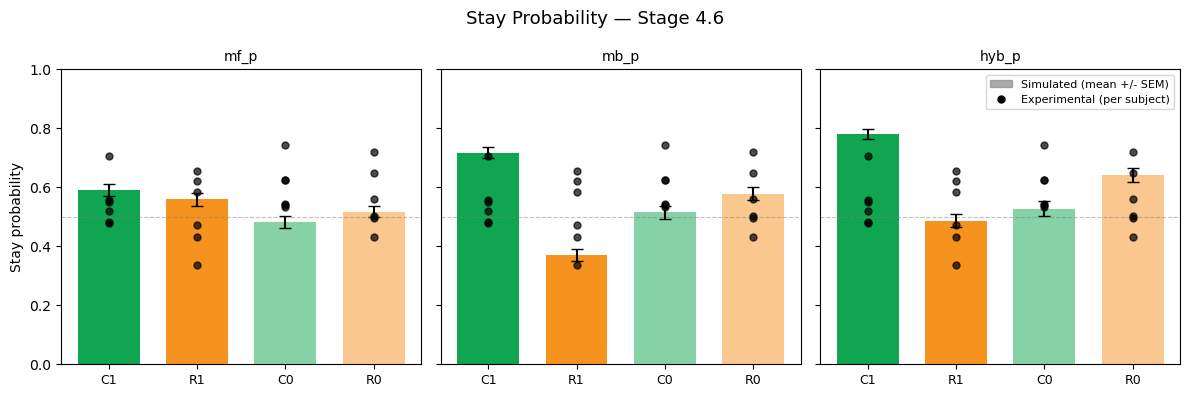

Saved: /gpfs/radev/project/kuan/my483/RL_twostep/organized/figures/stay_prob_stage4.6.png


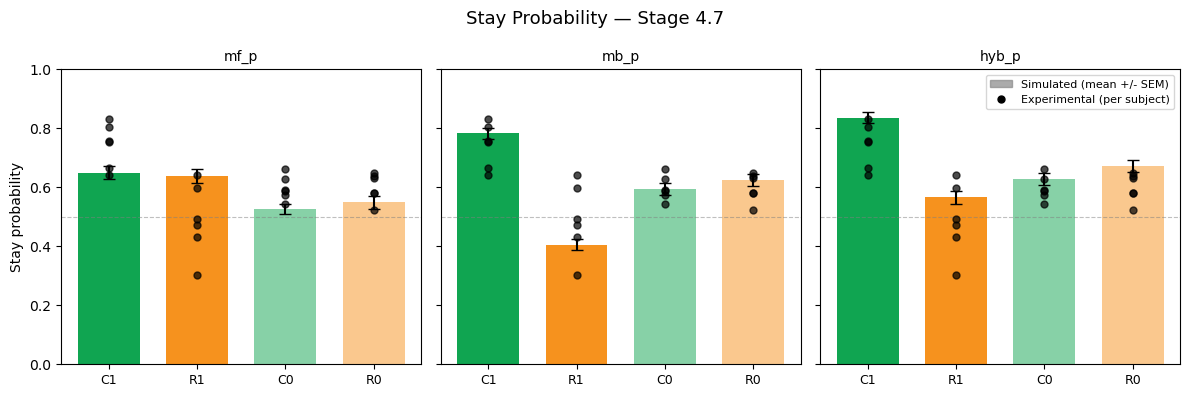

Saved: /gpfs/radev/project/kuan/my483/RL_twostep/organized/figures/stay_prob_stage4.7.png


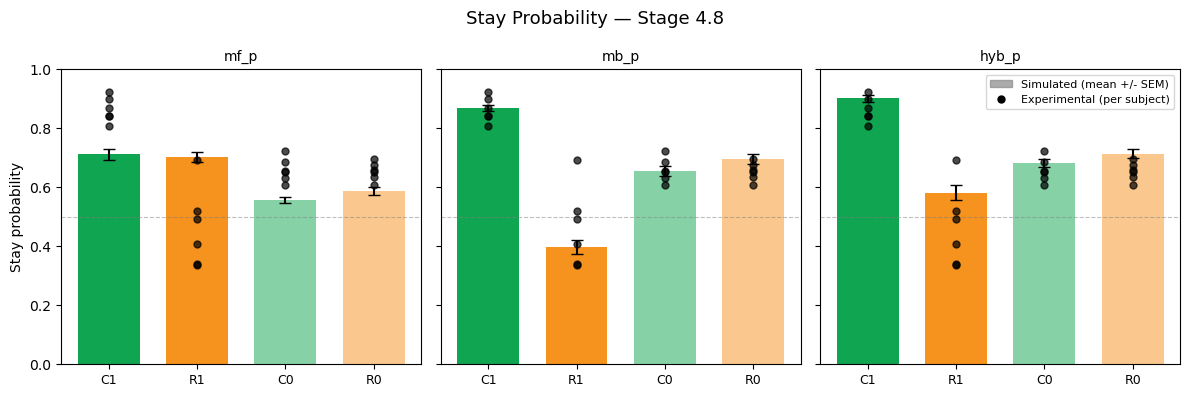

Saved: /gpfs/radev/project/kuan/my483/RL_twostep/organized/figures/stay_prob_stage4.8.png


In [17]:
# ── Cell 12: Stay probability plots ───────────────────────────────────────
#
# One figure per stage; one subplot per model.
# Bars = simulated mean (averaged first across sessions per subject,
# then across subjects); error bars = SEM across subjects.
# Dots = experimental per-subject mean.
# Green = common transition, Orange = rare transition (lighter = unrewarded)

STAGES_TO_PLOT = ['4.6', '4.7', '4.8']  # plot only later stages where stay prob is more stable
if df_all.empty:
    print('No results to plot. Run Cell 9 first.')
else:
    for stage in STAGES_TO_PLOT:
        df_stage = df_all[df_all['stage'] == stage]
        models_here = [m for m in MODELS_TO_PLOT
                       if m in df_stage['model'].unique()]
        if not models_here:
            continue

        fig, axes = plt.subplots(1, len(models_here),
                                 figsize=(4 * len(models_here), 4),
                                 sharey=True)
        if len(models_here) == 1:
            axes = [axes]
        fig.suptitle(f'Stay Probability — Stage {stage}', fontsize=13)

        for ax, model_key in zip(axes, models_here):
            df_m = df_stage[df_stage['model'] == model_key]

            # Per-subject mean across sessions
            sim_cols = [f'sim_stay_{c}_mean' for c in COND_LABELS]
            exp_cols = [f'exp_stay_{c}'      for c in COND_LABELS]
            subj_sim = df_m.groupby('subject')[sim_cols].mean()
            subj_exp = df_m.groupby('subject')[exp_cols].mean()

            # Mean +/- SEM across subjects
            sim_mean = subj_sim.mean()
            sim_sem  = subj_sim.sem()

            x = np.arange(4)
            for xi in x:
                ax.bar(xi, sim_mean.iloc[xi],
                       yerr=sim_sem.iloc[xi],
                       color=COND_COLORS[xi],
                       alpha=COND_ALPHA[xi],
                       capsize=4,
                       error_kw={'linewidth': 1.5},
                       width=0.7)

            # Experimental per-subject dots
            for subj in subj_exp.index:
                ax.plot(x, subj_exp.loc[subj].values,
                        'o', color='k', ms=5, alpha=0.7,
                        zorder=5)

            ax.set_xticks(x)
            ax.set_xticklabels(COND_DISPLAY, fontsize=9)
            ax.set_title(model_key, fontsize=10)
            ax.set_ylim(0, 1)
            ax.axhline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
            if ax is axes[0]:
                ax.set_ylabel('Stay probability')

        sim_patch = mpatches.Patch(color='#888888', alpha=0.7, label='Simulated (mean +/- SEM)')
        exp_dot   = plt.Line2D([0], [0], marker='o', color='k',
                               linestyle='', ms=5, label='Experimental (per subject)')
        axes[-1].legend(handles=[sim_patch, exp_dot], loc='upper right',
                        fontsize=8, framealpha=0.8)

        plt.tight_layout()
        fig_path = os.path.join(FIGURES_DIR, f'stay_prob_stage{stage}.png')
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fig_path}')


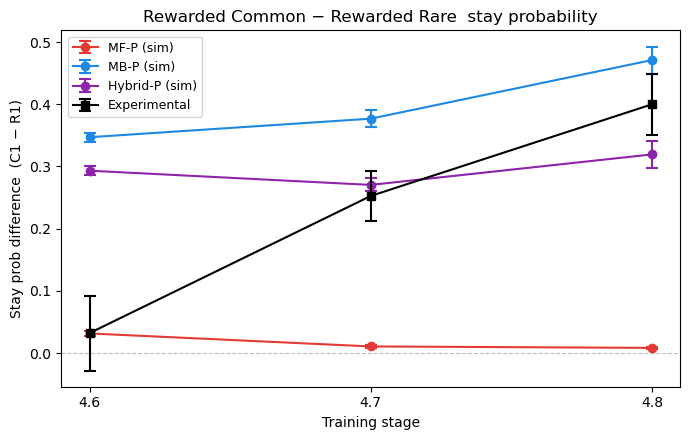

Saved: /gpfs/radev/project/kuan/my483/RL_twostep/organized/figures/stay_prob_C1minusR1_vs_stage.png


In [20]:
# ── Cell 12b: (C1 − R1) vs training stage ─────────────────────────────────
#
# Plots the difference between rewarded-common and rewarded-rare stay
# probability across training stages.  This "MB index" captures the degree
# of model-based behaviour: a large positive difference means the agent
# stays more after common-rewarded transitions than rare-rewarded ones.
#
# Lines: one per model (simulated) + experimental (black).
# Error bars: SEM across subjects.

STAGES_TO_PLOT_STAY = ['4.6', '4.7', '4.8']
MODELS_TO_PLOT_STAY = ['mf_p', 'mb_p', 'hyb_p']

if df_all.empty:
    print('No results to plot. Run Cell 9 first.')
else:
    df_all['stage'] = df_all['stage'].astype(str)

    MODEL_COLORS = {'mf_p': '#E53935', 'mb_p': '#1E88E5', 'hyb_p': '#8E24AA'}
    MODEL_LABELS = {'mf_p': 'MF-P (sim)', 'mb_p': 'MB-P (sim)', 'hyb_p': 'Hybrid-P (sim)'}

    models_here = [m for m in MODELS_TO_PLOT_STAY if m in df_all['model'].unique()]

    fig, ax = plt.subplots(figsize=(7, 4.5))

    # ── Simulated per-subject (C1 - R1) at each stage ────────────────────
    for model_key in models_here:
        stage_means, stage_sems = [], []
        stages_valid = []

        for stage in STAGES_TO_PLOT_STAY:
            df_ms = df_all[(df_all['model'] == model_key) & (df_all['stage'] == stage)]
            if df_ms.empty:
                continue

            subj = df_ms.groupby('subject').agg(
                sim_c1=('sim_stay_rew_com_mean', 'mean'),
                sim_r1=('sim_stay_rew_rare_mean', 'mean'),
            )
            subj['diff'] = subj['sim_c1'] - subj['sim_r1']
            stage_means.append(subj['diff'].mean())
            stage_sems.append(subj['diff'].sem())
            stages_valid.append(stage)

        if stages_valid:
            x = np.arange(len(stages_valid))
            m = np.array(stage_means)
            s = np.array(stage_sems)
            color = MODEL_COLORS.get(model_key, '#555555')
            ax.errorbar(x, m, yerr=s, fmt='o-', color=color, capsize=4,
                        capthick=1.5, label=MODEL_LABELS.get(model_key, model_key))

    # ── Experimental (identical across models — take from first available) ─
    ref_model = models_here[0] if models_here else None

    if ref_model is not None:
        exp_stage_means, exp_stage_sems = [], []
        exp_stages_valid = []

        for stage in STAGES_TO_PLOT_STAY:
            df_ms = df_all[(df_all['model'] == ref_model) & (df_all['stage'] == stage)]
            if df_ms.empty:
                continue
            subj = df_ms.groupby('subject').agg(
                exp_c1=('exp_stay_rew_com', 'mean'),
                exp_r1=('exp_stay_rew_rare', 'mean'),
            )
            subj['diff'] = subj['exp_c1'] - subj['exp_r1']
            exp_stage_means.append(subj['diff'].mean())
            exp_stage_sems.append(subj['diff'].sem())
            exp_stages_valid.append(stage)

        if exp_stages_valid:
            x = np.arange(len(exp_stages_valid))
            m = np.array(exp_stage_means)
            s = np.array(exp_stage_sems)
            ax.errorbar(x, m, yerr=s, fmt='s-', color='black', capsize=4,
                        capthick=1.5, label='Experimental', zorder=10)

    ax.set_xticks(np.arange(len(STAGES_TO_PLOT_STAY)))
    ax.set_xticklabels(STAGES_TO_PLOT_STAY)
    ax.set_xlabel('Training stage')
    ax.set_ylabel('Stay prob difference  (C1 − R1)')
    ax.set_title('Rewarded Common − Rewarded Rare  stay probability')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9, framealpha=0.8)
    plt.tight_layout()

    fig_path = os.path.join(FIGURES_DIR, 'stay_prob_C1minusR1_vs_stage.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')


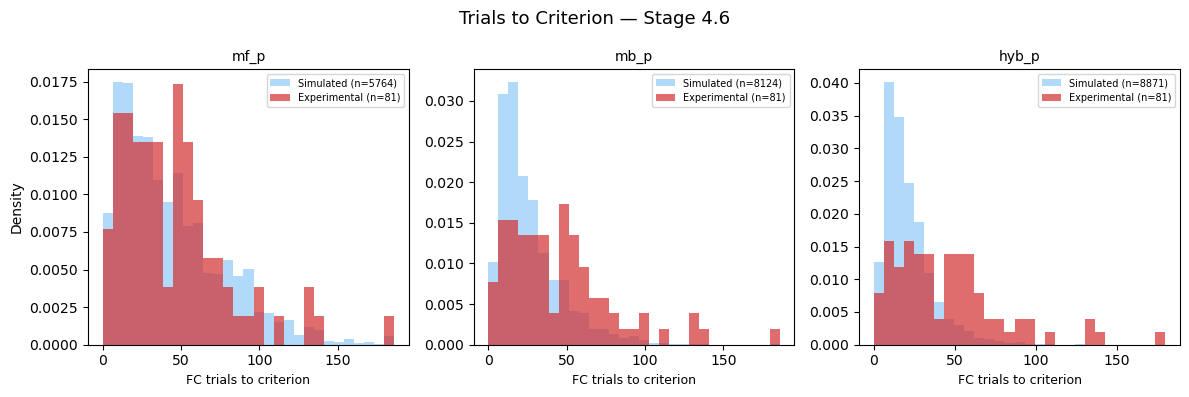

Saved: /gpfs/radev/project/kuan/my483/RL_twostep/organized/figures/trials_to_criterion_stage4.6.png


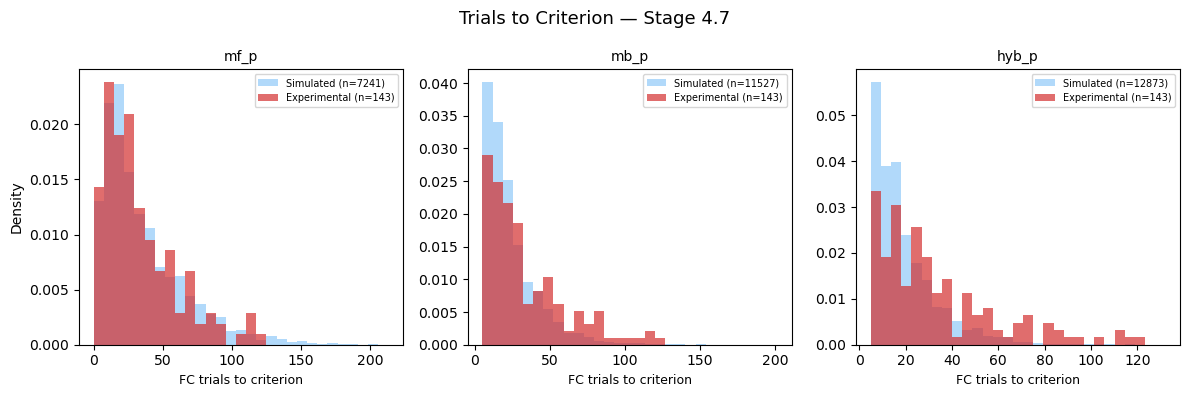

Saved: /gpfs/radev/project/kuan/my483/RL_twostep/organized/figures/trials_to_criterion_stage4.7.png


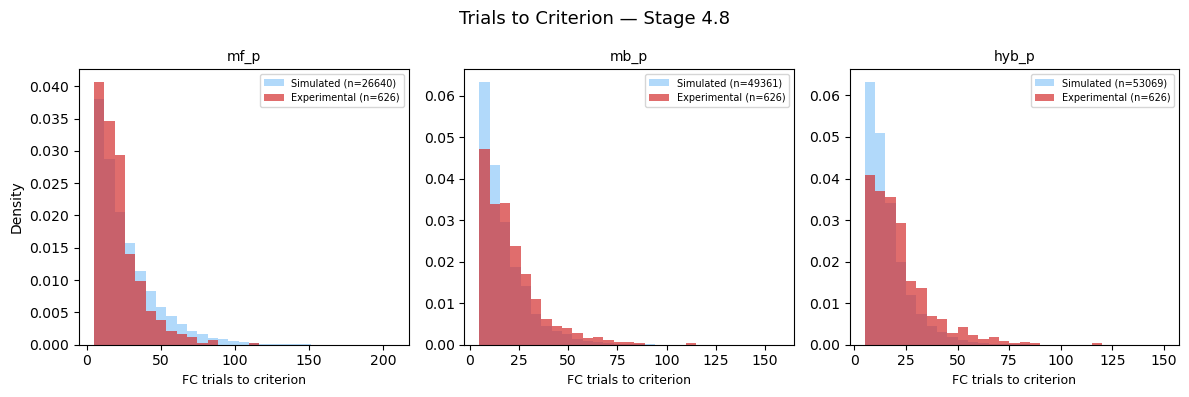

Saved: /gpfs/radev/project/kuan/my483/RL_twostep/organized/figures/trials_to_criterion_stage4.8.png


In [15]:
# ── Cell 13: Trials-to-criterion distribution plots ───────────────────────
#
# One figure per stage; one subplot per model.
# X-axis: number of FC trials to criterion (individual reversal level).
# Y-axis: density (both histograms normalised so they're visually comparable
#          even though N_SIM gives ~100x more simulated values than experimental).
# Blue histogram  = simulated individual reversal TTC values (pooled across
#                   all sessions × N_SIM repeats).
# Red histogram   = experimental individual reversal TTC values (pooled across
#                   all sessions).
# Same unit as OIST: each data point = one block reversal, not one session mean.

STAGES_TO_PLOT_TTC = ['4.6', '4.7', '4.8']  # stages with enough reversals

if df_all.empty:
    print('No results to plot. Run Cell 9 first.')
elif not has_ttc_lists:
    print('TTC list columns not found in CSVs. Re-run Cell 9 with FORCE_RERUN=True.')
else:
    for stage in STAGES_TO_PLOT_TTC:
        df_stage = df_all[df_all['stage'] == stage]
        models_here = [m for m in MODELS_TO_PLOT
                       if m in df_stage['model'].unique()]
        if not models_here:
            continue

        fig, axes = plt.subplots(1, len(models_here),
                                 figsize=(4 * len(models_here), 4),
                                 sharey=False)
        if len(models_here) == 1:
            axes = [axes]
        fig.suptitle(f'Trials to Criterion — Stage {stage}', fontsize=13)

        for ax, model_key in zip(axes, models_here):
            df_m = df_stage[df_stage['model'] == model_key]

            # Pool individual reversal TTC values across all sessions
            sim_vals = []
            exp_vals = []
            for _, row in df_m.iterrows():
                sim_vals.extend(_parse_ttc_list(row['sim_ttc_list']))
                exp_vals.extend(_parse_ttc_list(row['exp_ttc_list']))

            sim_vals = np.array(sim_vals)
            exp_vals = np.array(exp_vals)

            if len(sim_vals) > 0 or len(exp_vals) > 0:
                all_vals = np.concatenate([v for v in [sim_vals, exp_vals] if len(v) > 0])
                bins = np.linspace(all_vals.min(), all_vals.max(), 30)

                # density=True normalises both histograms to the same total area,
                # so experimental (n≈600) and simulated (n≈60000) are comparable
                ax.hist(sim_vals, bins=bins, color='#90CAF9', alpha=0.7,
                        density=True,
                        label=f'Simulated (n={len(sim_vals)})')
                ax.hist(exp_vals, bins=bins, color='#D32F2F', alpha=0.7,
                        density=True,
                        label=f'Experimental (n={len(exp_vals)})')

            ax.set_xlabel('FC trials to criterion', fontsize=9)
            ax.set_ylabel('Density' if ax is axes[0] else '')
            ax.set_title(model_key, fontsize=10)
            ax.legend(fontsize=7, framealpha=0.8)

        plt.tight_layout()
        fig_path = os.path.join(FIGURES_DIR, f'trials_to_criterion_stage{stage}.png')
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fig_path}')


In [16]:
# ── Wasserstein distance between sim and exp TTC distributions ────────────
#
# Uses individual reversal-level TTC values (same unit as OIST reference).
# OIST reference Wasserstein distances (hyb model):
#   4.6: 27.49   4.7: 14.19   4.8: 5.02
from scipy.stats import wasserstein_distance

print("Wasserstein distance (individual reversal TTC, sim vs exp):")
for stage in STAGES_TO_PLOT_TTC:
    df_stage = df_all[df_all['stage'] == stage]
    for model_key in MODELS_TO_PLOT:
        df_m = df_stage[df_stage['model'] == model_key]
        sim_vals, exp_vals = [], []
        for _, row in df_m.iterrows():
            sim_vals.extend(_parse_ttc_list(row['sim_ttc_list']))
            exp_vals.extend(_parse_ttc_list(row['exp_ttc_list']))
        if sim_vals and exp_vals:
            dist = wasserstein_distance(sim_vals, exp_vals)
            print(f"  Stage {stage} | {model_key}: {dist:.2f}  "
                  f"(n_sim={len(sim_vals)}, n_exp={len(exp_vals)})")

Wasserstein distance (individual reversal TTC, sim vs exp):
  Stage 4.6 | mf_p: 3.56  (n_sim=5764, n_exp=81)
  Stage 4.6 | mb_p: 19.33  (n_sim=8124, n_exp=81)
  Stage 4.6 | hyb_p: 24.62  (n_sim=8871, n_exp=81)
  Stage 4.7 | mf_p: 2.72  (n_sim=7241, n_exp=143)
  Stage 4.7 | mb_p: 9.90  (n_sim=11527, n_exp=143)
  Stage 4.7 | hyb_p: 13.82  (n_sim=12873, n_exp=143)
  Stage 4.8 | mf_p: 5.14  (n_sim=26640, n_exp=626)
  Stage 4.8 | mb_p: 3.76  (n_sim=49361, n_exp=626)
  Stage 4.8 | hyb_p: 5.39  (n_sim=53069, n_exp=626)
